In [1]:
#imports
from sklearn.datasets import fetch_openml
import numpy as np
from brian2 import *
from tqdm import tqdm
import os
import gc

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'

from constants import *
from equations import *
from network import *

In [2]:
#download mnist data
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.to_numpy()

#spliting into train and test sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [3]:
time_per_block = 50 * ms
blocks_per_image = 7  # 350ms
blocks_per_rest = 3   # 150ms
total_blocks = blocks_per_image + blocks_per_rest 
time_per_image_ms = total_blocks * (time_per_block / ms) # 500.0 ms
weights_path = './trained_model/weights.npy'
thetas_path = './trained_model/thetas.npy'
labels_path = './trained_model/neuron_labels.npy'

In [4]:
def assign_neuron_labels(X_train_data, y_train_data, num_examples=10000, batch_size=1000):
    
    net, spike_monitor, inp_group = build_network_test()
    net['s_inp_exc'].w = np.load(weights_path)
    net['exc'].theta = np.load(thetas_path) * volt 

    spike_rates = np.zeros((n_e, 10))
    num_batches = num_examples // batch_size
    batch_duration = batch_size * total_blocks * time_per_block
    previous_total_spikes = 0

    for batch_idx in range(num_batches):
        print(f"\n--- Batch {batch_idx + 1} / {num_batches} ---")
        
        batch_start_time = batch_idx * batch_duration
        
        start_img = batch_idx * batch_size
        end_img = start_img + batch_size
        X_batch = X_train_data[start_img : end_img]
        y_batch = y_train_data[start_img : end_img]
        
        # Build the Rates Array
        rates_array = np.zeros((batch_size * total_blocks, n_input), dtype=np.float32)
        for idx in range(batch_size):
            img_rates = X_batch[idx] / 4.0 
            start_idx_arr = idx * total_blocks
            rates_array[start_idx_arr : start_idx_arr + blocks_per_image, :] = img_rates
            
        input_rates = TimedArray(rates_array * Hz, dt=time_per_block)
        
        net.run(batch_duration, report='text', report_period=600*second)
        
        # Slice out new spikes
        current_total_spikes = len(spike_monitor.t)
        new_spike_times = spike_monitor.t[previous_total_spikes : current_total_spikes]
        new_spike_neurons = spike_monitor.i[previous_total_spikes : current_total_spikes]
        
        relative_times_ms = (new_spike_times - batch_start_time) / ms
        image_indices = np.floor(relative_times_ms / time_per_image_ms).astype(int)
        
        # Tally the spikes
        for i in range(len(new_spike_neurons)):
            neuron_id = new_spike_neurons[i]
            img_id = image_indices[i]
            
            # out of bounds check
            if img_id < batch_size: 
                true_label = int(y_batch[img_id])
                spike_rates[neuron_id, true_label] += 1
                
        # Update
        previous_total_spikes = current_total_spikes
        
        # Cleanup
        del rates_array
        del input_rates
        gc.collect()

    # finds the class that received the most spikes for each neuron
    neuron_labels = np.argmax(spike_rates, axis=1)
    
    return neuron_labels, spike_rates

In [5]:
labels, rate_matrix = assign_neuron_labels(X_train, y_train, num_examples=10000, batch_size=2000)
np.save(labels_path, labels)

Test Network built successfully!

--- Batch 1 / 5 ---
Starting simulation at t=0. s for a duration of 1. ks
0.4466858 ks (44%) simulated in 10m 0s, estimated 12m 23s remaining.
0.8931038 ks (89%) simulated in 20m 0s, estimated 2m 24s remaining.
1. ks (100%) simulated in 22m 23s

--- Batch 2 / 5 ---


WARNING    'i' is an internal variable of group 'inp', but also exists in the run namespace with the value 33483. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=1. ks for a duration of 1. ks
0.4461549 ks (44%) simulated in 10m 0s, estimated 12m 25s remaining.
0.8934399 ks (89%) simulated in 20m 0s, estimated 2m 23s remaining.
1. ks (100%) simulated in 22m 22s

--- Batch 3 / 5 ---


WARNING    'i' is an internal variable of group 'inp', but also exists in the run namespace with the value 32960. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=2. ks for a duration of 1. ks
0.4489879 ks (44%) simulated in 10m 0s, estimated 12m 16s remaining.
0.783031 ks (78%) simulated in 10h 30m 37s, estimated 2h 54m 44s remaining.
1. ks (100%) simulated in 10h 35m 28s

--- Batch 4 / 5 ---


WARNING    'i' is an internal variable of group 'inp', but also exists in the run namespace with the value 35171. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=3. ks for a duration of 1. ks
0.4490421 ks (44%) simulated in 10m 0s, estimated 12m 16s remaining.
0.8978194 ks (89%) simulated in 20m 0s, estimated 2m 17s remaining.
1. ks (100%) simulated in 22m 17s

--- Batch 5 / 5 ---


WARNING    'i' is an internal variable of group 'inp', but also exists in the run namespace with the value 33097. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Starting simulation at t=4. ks for a duration of 1. ks
0.4467595 ks (44%) simulated in 10m 0s, estimated 12m 23s remaining.
0.8955193 ks (89%) simulated in 20m 0s, estimated 2m 20s remaining.
1. ks (100%) simulated in 22m 20s


In [10]:
def evaluate_test_set(X_test_data, y_test_data, num_examples=10000, batch_size=1000):
    
    net, spike_monitor, inp_group = build_network_test()
    net['s_inp_exc'].w = np.load(weights_path)
    net['exc'].theta = np.load(thetas_path) * volt 
    neuron_labels = np.load(labels_path)

    num_batches = num_examples // batch_size
    batch_duration = batch_size * total_blocks * time_per_block
    
    correct_predictions = 0
    confusion_matrix = np.zeros((10, 10), dtype=int)
    previous_total_spikes = 0

    for batch_idx in range(num_batches):
        print(f"\n--- Batch {batch_idx + 1} / {num_batches} ---")
        batch_start_time = batch_idx * batch_duration
        
        start_img = batch_idx * batch_size
        end_img = start_img + batch_size
        X_batch = X_test_data[start_img : end_img]
        y_batch = y_test_data[start_img : end_img]
        
        # Build the Rates Array
        rates_array = np.zeros((batch_size * total_blocks, n_input), dtype=np.float32)
        for idx in range(batch_size):
            img_rates = X_batch[idx] / 4.0 
            start_idx_arr = idx * total_blocks
            rates_array[start_idx_arr : start_idx_arr + blocks_per_image, :] = img_rates
            
        input_rates = TimedArray(rates_array * Hz, dt=time_per_block)
        
        # Run
        net.run(batch_duration, report='text', report_period=600*second)
        
        current_total_spikes = len(spike_monitor.t)
        new_spike_times = spike_monitor.t[previous_total_spikes : current_total_spikes]
        new_spike_neurons = spike_monitor.i[previous_total_spikes : current_total_spikes]
        
        relative_times_ms = (new_spike_times - batch_start_time) / ms
        image_indices = np.floor(relative_times_ms / time_per_image_ms).astype(int)
        
        # Evaluate every image in this batch
        for img_id in range(batch_size):
            true_label = int(y_batch[img_id])
            
            # all the spikes during this timeframe
            spike_mask = (image_indices == img_id)
            neurons_that_spiked = new_spike_neurons[spike_mask]
            
            if len(neurons_that_spiked) == 0:
                predicted_label = np.random.randint(0, 10)
            else:
                spiked_classes = neuron_labels[neurons_that_spiked]
                class_counts = np.bincount(spiked_classes, minlength=10)
                predicted_label = np.argmax(class_counts)
                
            # Log the results
            if predicted_label == true_label:
                correct_predictions += 1
            confusion_matrix[true_label, predicted_label] += 1
                
        # Update 
        previous_total_spikes = current_total_spikes
        
        # Cleanup
        del rates_array
        del input_rates
        gc.collect()

    accuracy = (correct_predictions / num_examples) * 100.0
    
    print("\n" + "="*40)
    print(f" FINAL TEST ACCURACY: {accuracy:.2f}% ")
    print("="*40)
    
    return accuracy, confusion_matrix

In [11]:
final_acc, conf_matrix = evaluate_test_set(X_test, y_test, num_examples=10000, batch_size=2000)

Test Network built successfully!

--- Batch 1 / 5 ---
Starting simulation at t=0. s for a duration of 1. ks
0.4761965 ks (47%) simulated in 10m 0s, estimated 11m 0s remaining.
0.9264797 ks (92%) simulated in 20m 0s, estimated 1m 35s remaining.
1. ks (100%) simulated in 21m 38s

--- Batch 2 / 5 ---
Starting simulation at t=1. ks for a duration of 1. ks
0.4487798 ks (44%) simulated in 10m 0s, estimated 12m 17s remaining.
0.897887 ks (89%) simulated in 20m 0s, estimated 2m 16s remaining.
1. ks (100%) simulated in 22m 16s

--- Batch 3 / 5 ---
Starting simulation at t=2. ks for a duration of 1. ks
0.4475621 ks (44%) simulated in 10m 0s, estimated 12m 21s remaining.
0.8956372 ks (89%) simulated in 20m 0s, estimated 2m 20s remaining.
1. ks (100%) simulated in 22m 19s

--- Batch 4 / 5 ---
Starting simulation at t=3. ks for a duration of 1. ks
0.4464428 ks (44%) simulated in 10m 0s, estimated 12m 24s remaining.
0.893239 ks (89%) simulated in 20m 0s, estimated 2m 23s remaining.
1. ks (100%) simu

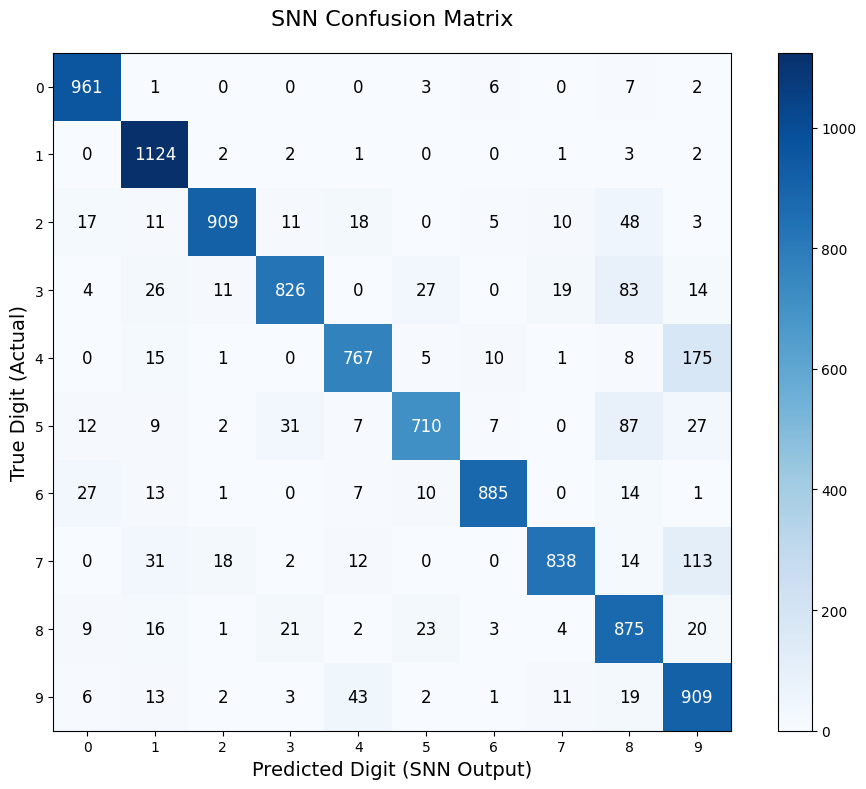

In [12]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm):

    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(cax)

    # Set up the axes labels
    classes = np.arange(10)
    ax.set_xticks(classes)
    ax.set_yticks(classes)
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    
    # Add axis titles
    ax.set_ylabel('True Digit (Actual)', fontsize=14)
    ax.set_xlabel('Predicted Digit (SNN Output)', fontsize=14)
    ax.set_title('SNN Confusion Matrix', fontsize=16, pad=20)

    # Loop over the matrix data and add the raw numbers as text inside the boxes
    # change the text color to white if the box background is very dark
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > threshold else "black",
                    fontsize=12)

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(conf_matrix)